# 7. EDA 3 — 저광도 특화 모델 파이프라인

## 1. 프로젝트 주제
- **주제**: 보이지 않는 노인들 — 야간광으로 발견한 고령화 사각지대와 AI의 시선
- **가설**:
  1. 고령화율이 높고 야간 조도가 어두운 지역은 거래 데이터 자체가 적어서, 전국 통합 모델이 제대로 학습하기 어렵다 (데이터 소외)
  2. 통합 단일 모델은 수도권 데이터에 치우쳐 있어서, 지방 소외 지역 예측에서 오차가 유독 크게 나온다 (알고리즘 소외)

## 2. 분석 방향
- 전국 실거래 약 249만건 + KOSIS 고령화율 + VIIRS 위성 야간광을 시군구 코드 기준으로 통합
- 저광도 고령화 지역 데이터만 따로 추출 → 특화 모델 구성 후 예측 오차 감소 여부 검증


### 1단계: 환경 설정
- Mac / Windows 환경에 맞게 한글 폰트 설정
- 마이너스 기호 깨짐 방지 설정 추가


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#  한글 깨짐 방지 설정 (Windows/Mac 호환)
import platform
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Windows
    plt.rc('font', family='Malgun Gothic')
    
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font=platform.system() == 'Darwin' and 'AppleGothic' or 'Malgun Gothic')

### 2단계: 데이터 로드 및 메모리 최적화
- 249만건 데이터를 그대로 읽으면 메모리 부담이 커서, float64→float32 / int64→int32 등으로 타입 다운캐스팅
- 중복값 많은 문자열 컬럼(cluster_name, SGG_NM 등)은 category 타입으로 변환


In [8]:
# 데이터 로드
df_raw = pd.read_csv('apt_ml_master.csv', encoding='utf-8-sig', low_memory=False)

def optimize_memory_usage(data):
    start_mem = data.memory_usage(deep=True).sum() / (1024 ** 2)
    
    # float64→float32, int64→int32/int16 변환 (메모리 절약)
    for col in data.select_dtypes(include=['float64']).columns:
        data[col] = data[col].astype('float32')
    for col in data.select_dtypes(include=['int64']).columns:
        if data[col].max() < 32767 and data[col].min() > -32768:
            data[col] = data[col].astype('int16')
        else:
            data[col] = data[col].astype('int32')
            
    # 중복값 많은 문자열 → category 타입
    for col in ['cluster_name', 'SGG_NM'] :
        if col in data.columns:
            data[col] = data[col].astype('category')
            
    end_mem = data.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"-> 메모리 최적화 완료: {start_mem:.2f}MB -> {end_mem:.2f}MB (절감률: {((start_mem - end_mem) / start_mem) * 100:.1f}%)")
    return data

df = optimize_memory_usage(df_raw)

-> 메모리 최적화 완료: 3025.53MB -> 2410.93MB (절감률: 20.3%)


### 3단계: 데이터 정제 및 저광도 구역 추출
- 타겟(dealAmount_num) 결측치 제거
- 군위군은 2023년에 대구로 편입되면서 통계 코드가 바뀌어서 2019~2022년 고령화율이 누락됨. 기존 코드(37310) 기준 연도별 실측값으로 직접 채움
- 저광도 데이터 추출 시 `.copy()`로 원본 보호


C:\Users\shy66\AppData\Local\Temp\ipykernel_26252\1258098754.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  isolation_evidence = df.groupby('cluster_name').agg(


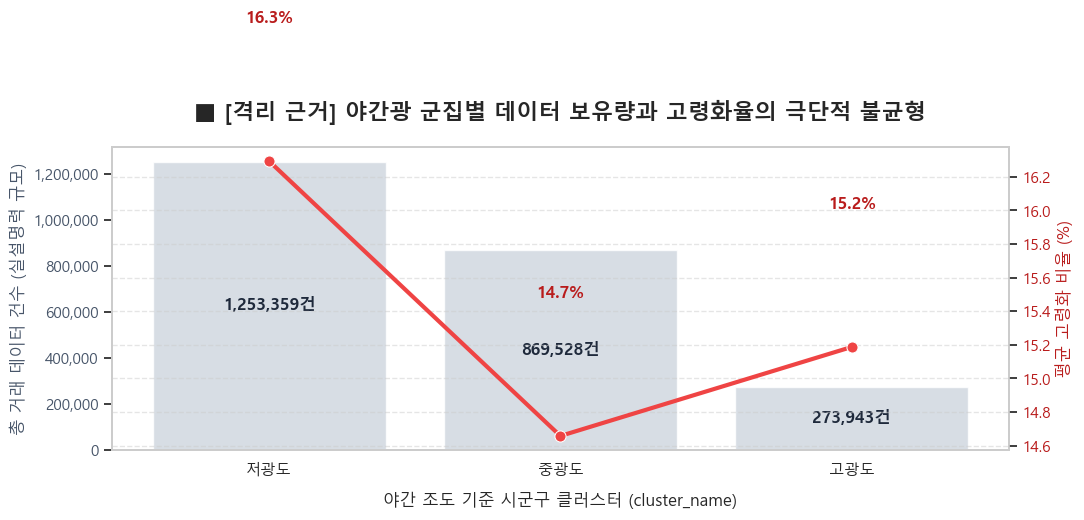

저광도(사각지대) 데이터 추출 완료: 1,253,359건


In [ ]:
# 1. 타겟(실거래가) 결측치 제거
df = df.dropna(subset=['dealAmount_num'])

# 2. 군위군 고령화율 결측 복원 (2023년 대구 편입으로 코드 바뀌면서 19~22년 데이터 누락됨)
aging_rate_df = pd.read_csv('aging_rate_2019_2023.csv', encoding='utf-8-sig')
gunwi_map = aging_rate_df[aging_rate_df['SGG_CODE'] == 37310].set_index('year')['고령화율'].to_dict()

# 연도별 고령화율 딕셔너리 매핑
mask_gunwi = df['고령화율'].isna()
df.loc[mask_gunwi, '고령화율'] = df.loc[mask_gunwi, 'dealYear'].map(gunwi_map)
df['aptDong'] = df['aptDong'].fillna('')

# 3. 저광도 데이터만 따로 추출 (.copy()로 원본 보호)
df_low_light = df[df['cluster_name'] == '저광도'].copy()

print(f"저광도(사각지대) 데이터 추출 완료: {len(df_low_light):,}건")

### 4단계: 파생 피처 만들기

1. **`nl_growth_trend` (야간광 변화량)**
   - 2023 야간광 - 2019 야간광
   - 개발 활발 지역은 야간광 증가 / 사각지대는 거의 변화 없거나 감소

2. **`sgg_yearly_volume` (시군구 연간 거래량)**
   - 시군구별 연도별 거래 건수
   - 거래량이 적을수록 모델 학습이 불안정 → 이 특성을 피처로 반영

3. **`apt_age` (아파트 노후도)**
   - 거래연도 - 건축연도
   - 서울은 오래될수록 재건축 기대로 오히려 비싸지는 반면, 지방 사각지대는 오래될수록 싸지는 경향 → 이 차이를 모델이 반영하도록 피처로 포함

4. **`aging_intensity_per_nl` (야간광 대비 고령화 집중도)**
   - 고령화율 / (야간광 평균 + 1e-5)
   - 불 꺼진 동네에 노인이 얼마나 집중돼 있는지 수치화 — 사각지대 특성을 직접 반영


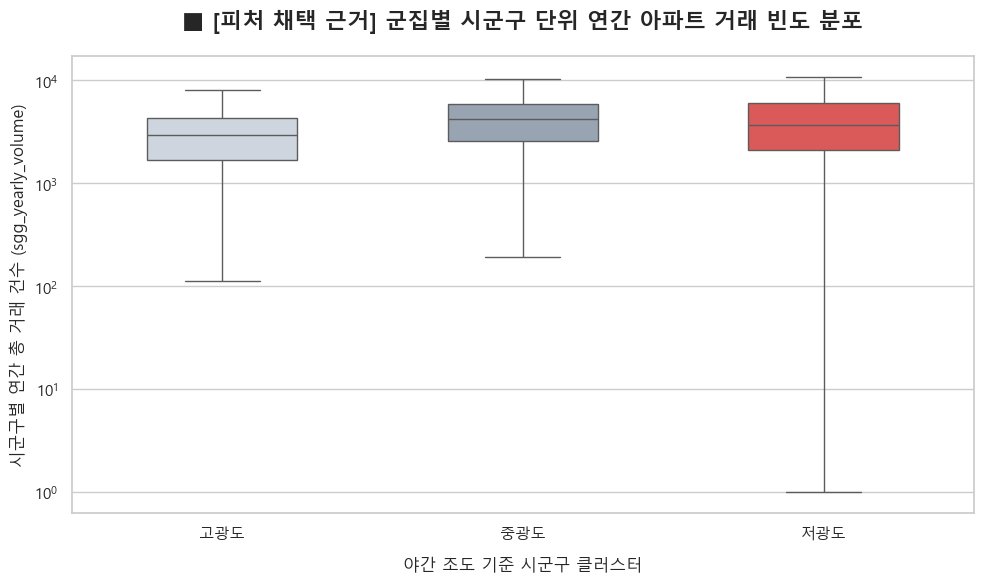

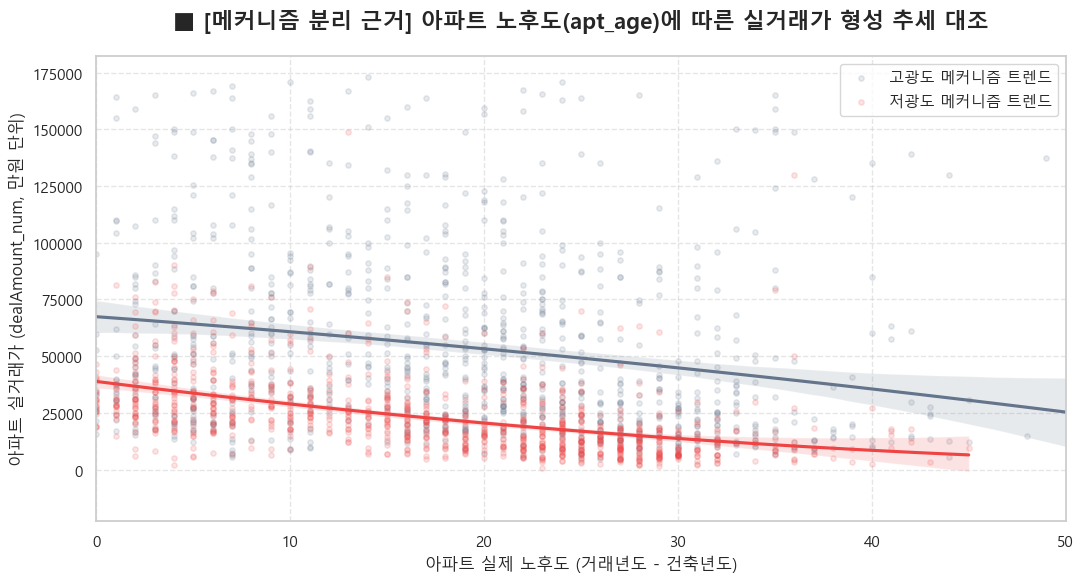

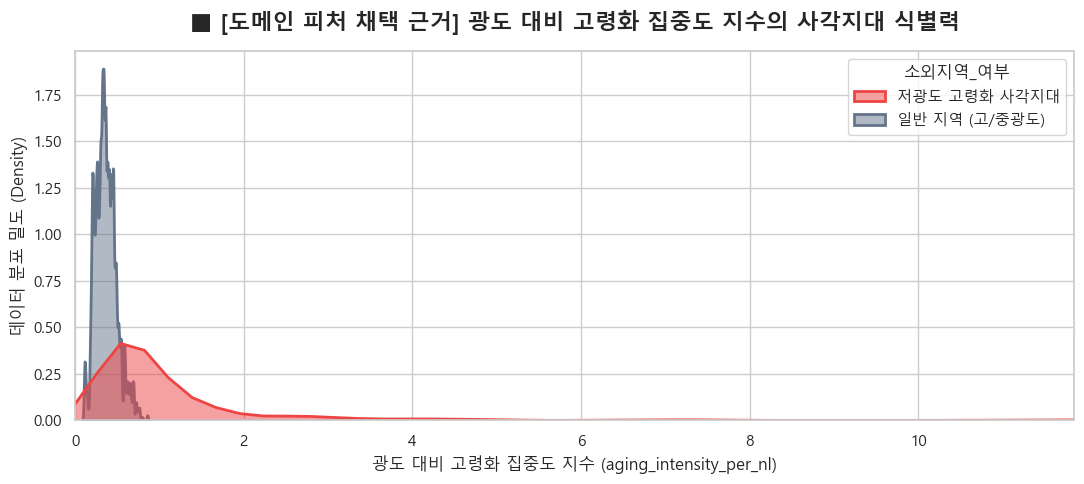

In [21]:
# [피처 1] 야간광 변화량 (2023 - 2019)
df_low_light['nl_growth_trend'] = df_low_light['nl_2023'] - df_low_light['nl_2019']

# [피처 2] 시군구별 연간 거래 건수
df_low_light['sgg_yearly_volume'] = df_low_light.groupby(['KOSIS_SGG_CODE', 'dealYear'])['dealAmount_num'].transform('count')

plt.figure(figsize=(10, 6))

# 클러스터별 거래량 분포 확인
df_temp = df.copy()
df_temp['sgg_yearly_volume'] = df_temp.groupby(['KOSIS_SGG_CODE', 'dealYear'])['dealAmount_num'].transform('count')

# 클러스터 순서 지정
cluster_order = ['고광도', '중광도', '저광도']
available_order = [c for c in cluster_order if c in df_temp['cluster_name'].unique()]

# 박스플롯 그리기 (저광도 강조)
palette_colors = {'고광도': '#cbd5e1', '중광도': '#94a3b8', '저광도': '#ef4444'}

sns.boxplot(x='cluster_name', y='sgg_yearly_volume', data=df_temp, 
            order=available_order, palette=palette_colors, hue='cluster_name', legend=False, width=0.5)

plt.title('군집별 시군구 연간 아파트 거래 건수 분포', fontsize=16, pad=20, weight='bold')
plt.xlabel('야간 조도 기준 시군구 클러스터', fontsize=12, labelpad=10)
plt.ylabel('시군구별 연간 총 거래 건수 (sgg_yearly_volume)', fontsize=12)
plt.yscale('log') # 격차가 커서 로그 스케일 사용

plt.tight_layout()
plt.show()
del df_temp # 임시 데이터 삭제

# [피처 3] 아파트 노후도 (거래연도 - 건축연도)
df_low_light['apt_age'] = df_low_light['dealYear'] - df_low_light['buildYear']

# 샘플링 (그래프 성능 고려)
df_sample = df.copy()
df_sample['apt_age'] = df_sample['dealYear'] - df_sample['buildYear']

# 이상치(상위 1%) 제외
price_limit = df_sample['dealAmount_num'].quantile(0.99)
df_filtered = df_sample[df_sample['dealAmount_num'] <= price_limit]

# 클러스터별 추세선 시각화
plt.figure(figsize=(11, 6))

# 고광도 vs 저광도만 비교
target_clusters = [c for c in ['고광도', '저광도'] if c in df_filtered['cluster_name'].unique()]

for cluster in target_clusters:
    cluster_data = df_filtered[df_filtered['cluster_name'] == cluster].sample(n=1000, random_state=42)
    color = '#ef4444' if cluster == '저광도' else '#64748b'
    
    # 노후도별 가격 경향 비교 (2차 회귀 곡선)
    sns.regplot(x='apt_age', y='dealAmount_num', data=cluster_data, order=2,
                label=f'{cluster} 메커니즘 트렌드', color=color, scatter_kws={'alpha': 0.15, 's': 15})

plt.title('아파트 노후도(apt_age)에 따른 실거래가 추세', fontsize=16, pad=20, weight='bold')
plt.xlabel('아파트 실제 노후도 (거래년도 - 건축년도)', fontsize=12)
plt.ylabel('아파트 실거래가 (dealAmount_num, 만원 단위)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 50) # 노후도 범위 제한

plt.tight_layout()
plt.show()

# [피처 4] 야간광 대비 고령화 집중도 (고령화율 / 야간광 평균)
df_low_light['aging_intensity_per_nl'] = df_low_light['고령화율'] / (df_low_light['nightlight_avg'] + 1e-5)

plt.figure(figsize=(11, 5))

# 저광도 vs 일반 지역 비교용 임시 라벨 추가
df_low_light['소외지역_여부'] = '저광도 고령화 사각지대'
df_other = df[df['cluster_name'] != '저광도'].copy()
df_other['aging_intensity_per_nl'] = df_other['고령화율'] / (df_other['nightlight_avg'] + 1e-5)
df_other['소외지역_여부'] = '일반 지역 (고/중광도)'

df_total_density = pd.concat([df_low_light[['aging_intensity_per_nl', '소외지역_여부']], 
                               df_other[['aging_intensity_per_nl', '소외지역_여부']]])

# 두 지역 분포 비교 (KDE)
sns.kdeplot(data=df_total_density, x='aging_intensity_per_nl', hue='소외지역_여부', fill=True, 
            palette={'일반 지역 (고/중광도)': '#64748b', '저광도 고령화 사각지대': '#ef4444'}, alpha=0.5, linewidth=2)

plt.title('광도 대비 고령화 집중도 지수의 사각지대 식별력', fontsize=16, pad=15, weight='bold')
plt.xlabel('광도 대비 고령화 집중도 지수 (aging_intensity_per_nl)', fontsize=12)
plt.ylabel('데이터 분포 밀도 (Density)', fontsize=12)

# 상위 95% 지점까지만 표시 (꼬리 제거)
plt.xlim(0, df_total_density[df_total_density['소외지역_여부']=='저광도 고령화 사각지대']['aging_intensity_per_nl'].quantile(0.95)) 

# 임시 컬럼 삭제
df_low_light.drop(columns=['소외지역_여부'], inplace=True)

plt.tight_layout()
plt.show()

### 5단계: 피처 선별 정리

| 컬럼 그룹 | 대상 컬럼 | 선택 | 이유 |
| :--- | :--- | :---: | :--- |
| **건물 기본 정보** | `excluUseAr_num`, `floor_num`, `apt_age` | 사용 | 아파트 가격을 결정하는 기본 물리 변수 |
| **거래 시점** | `dealYear`, `dealMonth` | 사용 | 연도별 금리·부동산 정책 흐름을 반영하기 위해 |
| **지역 환경** | `고령화율`, `nightlight_avg` | 사용 | 사각지대 환경을 나타내는 핵심 변수 |
| **직접 만든 파생 변수** | `nl_growth_trend`, `sgg_yearly_volume`, `aging_intensity_per_nl` | 사용 | 데이터 소외·알고리즘 소외 가설을 반영한 변수들 |
| **원본/중복 수치** | `dealAmount`, `excluUseAr`, `floor` | 제외 | `_num` 전처리 버전이 있으니 중복 제거 |
| **고유 ID** | `bonbun`, `bubun`, `jibun`, `aptSeq` 등 | 제외 | 고유값이 너무 많으면 모델이 특정 아파트를 외워버리는 과적합이 생긴다 |
| **행정 코드 중복** | `sggCd`, `umdCd`, `roadNmCd` 등 | 제외 | KOSIS SGG_CODE로 이미 통일했으니 나머지는 불필요 |
| **사후 데이터** | `rgstDate`, `cdealDay`, `cdealType` | 제외 | 거래 체결 후에 생기는 정보라서 예측 시점엔 쓰면 안 됨 |


**Train / Test 분할**
- 7_EDA_1에서 정한 피처 기준으로 독립변수(X)와 종속변수(y) 분리
- 8:2 비율로 train/test 분할


In [ ]:
# 최종 피처 목록
features_to_use = [
    'excluUseAr_num', 'floor_num', 'apt_age', 'dealYear', 'dealMonth',
    '고령화율', 'nightlight_avg', 'nl_growth_trend', 'sgg_yearly_volume', 'aging_intensity_per_nl'
]
target_variable = 'dealAmount_num'

# X, y 분리
X_special = df_low_light[features_to_use]
y_special = df_low_light[target_variable]

# 8:2로 train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_special, y_special, test_size=0.2, random_state=42
)

print(f"train/test 분할 완료 (train: {X_train.shape[0]:,}건 / test: {X_test.shape[0]:,}건)")

train/test 분할 완료 (train: 1,002,687건 / test: 250,672건)


### 7단계: 저광도 특화 랜덤 포레스트 모델 학습
- 단일 트리는 데이터 변화에 예측이 흔들려서, 트리 100개를 합친 랜덤 포레스트 사용
- `max_depth=15`로 트리 깊이 제한 → 특이 거래 외우기 방지 (과적합 억제)
- `n_jobs=-1`로 CPU 코어 최대 활용 (학습 속도 향상)


In [ ]:
# 랜덤 포레스트 모델 정의
rf_special = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1 # CPU 병렬 처리
)

print("저광도 특화 모델 학습 중...")
rf_special.fit(X_train, y_train)
print("저광도 특화 모델 학습 완료")

저광도 특화 모델 학습 중...
저광도 특화 모델 학습 완료


### 8단계: 피처 중요도 확인
- 학습된 모델에서 각 피처의 예측 기여도 추출
- 직접 만든 야간광·고령화율 파생 변수들의 실제 기여도 검증
- 직접 만든 변수 빨간색 / 기본 건물 변수 회색으로 구분 표시


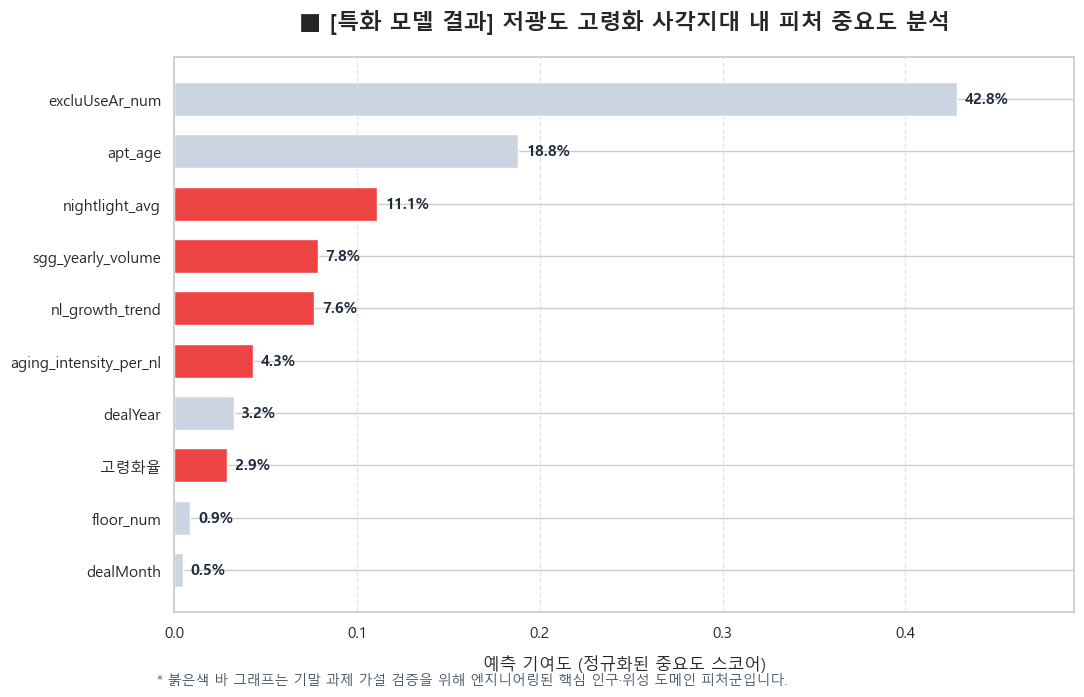

In [ ]:
# 피처 중요도 추출 및 정렬
importances_actual = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': rf_special.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(11, 7))

# 직접 만든 피처 목록 (색상 강조용)
domain_features = ['고령화율', 'nightlight_avg', 'nl_growth_trend', 'sgg_yearly_volume', 'aging_intensity_per_nl']

# 직접 만든 피처는 빨간색, 기본 건물 피처는 회색
bar_colors = ['#ef4444' if col in domain_features else '#cbd5e1' for col in importances_actual['Feature']]

bars = plt.barh(importances_actual['Feature'], importances_actual['Importance'], color=bar_colors, height=0.65)

# 막대 오른쪽에 퍼센트 표시
max_importance = importances_actual['Importance'].max()
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max_importance * 0.01), bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%', 
             va='center', ha='left', fontsize=11, weight='bold', color='#1e293b')

plt.title('저광도 고령화 사각지대 피처 중요도 분석 (특화 모델)', fontsize=16, pad=20, weight='bold')
plt.xlabel('예측 기여도 (정규화된 중요도 스코어)', fontsize=12, labelpad=10)
plt.xlim(0, max_importance * 1.15) # 레이블 잘림 방지
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 하단 캡션 추가
plt.figtext(0.15, 0.01, "* 붉은색 막대는 직접 만든 인구·야간광 관련 피처", 
            fontsize=10, style='italic', color='#475569')

plt.tight_layout()
plt.show()